In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import functional as TF
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
class OxfordPetsSegmentation(torch.utils.data.Dataset):
    def __init__(self, split='train'):
        self.dataset = OxfordIIITPet(
            root='.', download=True,
            target_types='segmentation'
        )
        self.transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor()
        ])
        self.split = split
        self.indices = list(range(len(self.dataset)))
        split_idx = int(0.8 * len(self.indices))
        self.indices = self.indices[:split_idx] if split == 'train' else self.indices[split_idx:]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, mask = self.dataset[self.indices[idx]]
        image = self.transform(image)
        mask = TF.resize(mask, (128, 128))
        mask = torch.tensor(np.array(mask), dtype=torch.float32)
        mask = (mask == 1).float().unsqueeze(0)  # Binary mask
        return image, mask

In [ ]:
train_dataset = OxfordPetsSegmentation(split='train')
test_dataset = OxfordPetsSegmentation(split='test')

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1)

100%|██████████| 792M/792M [00:35<00:00, 22.5MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.6MB/s]


In [ ]:
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        self.encoder1 = self.conv_block(3, 64)
        self.encoder2 = self.conv_block(64, 128)
        self.encoder3 = self.conv_block(128, 256)
        self.bottleneck = self.conv_block(256, 512)
        self.decoder1 = self.conv_block(512, 256)
        self.decoder2 = self.conv_block(256, 128)
        self.decoder3 = self.conv_block(128, 64)
        self.output_layer = nn.Conv2d(64, 1, kernel_size=1)

        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x1 = self.encoder1(x)
        x2 = self.encoder2(self.pool(x1))
        x3 = self.encoder3(self.pool(x2))
        x_bottleneck = self.bottleneck(self.pool(x3))
        x4 = self.decoder1(self.up(x_bottleneck))
        x5 = self.decoder2(self.up(x4))
        x6 = self.decoder3(self.up(x5))
        output = self.output_layer(x6)
        return torch.sigmoid(output)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)

loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

    print(f"\n🔍 Predictions after Epoch {epoch+1}")



Epoch [1/30], Loss: 0.5057

🔍 Predictions after Epoch 1
Epoch [2/30], Loss: 0.4351

🔍 Predictions after Epoch 2
Epoch [3/30], Loss: 0.4071

🔍 Predictions after Epoch 3
Epoch [4/30], Loss: 0.3693

🔍 Predictions after Epoch 4
Epoch [5/30], Loss: 0.3288

🔍 Predictions after Epoch 5
Epoch [6/30], Loss: 0.2984

🔍 Predictions after Epoch 6
Epoch [7/30], Loss: 0.2757

🔍 Predictions after Epoch 7
Epoch [8/30], Loss: 0.2566

🔍 Predictions after Epoch 8
Epoch [9/30], Loss: 0.2379

🔍 Predictions after Epoch 9
Epoch [10/30], Loss: 0.2267

🔍 Predictions after Epoch 10
Epoch [11/30], Loss: 0.2086

🔍 Predictions after Epoch 11
Epoch [12/30], Loss: 0.1961

🔍 Predictions after Epoch 12
Epoch [13/30], Loss: 0.1826

🔍 Predictions after Epoch 13
Epoch [14/30], Loss: 0.1701

🔍 Predictions after Epoch 14
Epoch [15/30], Loss: 0.1553

🔍 Predictions after Epoch 15
Epoch [16/30], Loss: 0.1427

🔍 Predictions after Epoch 16
Epoch [17/30], Loss: 0.1290

🔍 Predictions after Epoch 17
Epoch [18/30], Loss: 0.1144

🔍 P

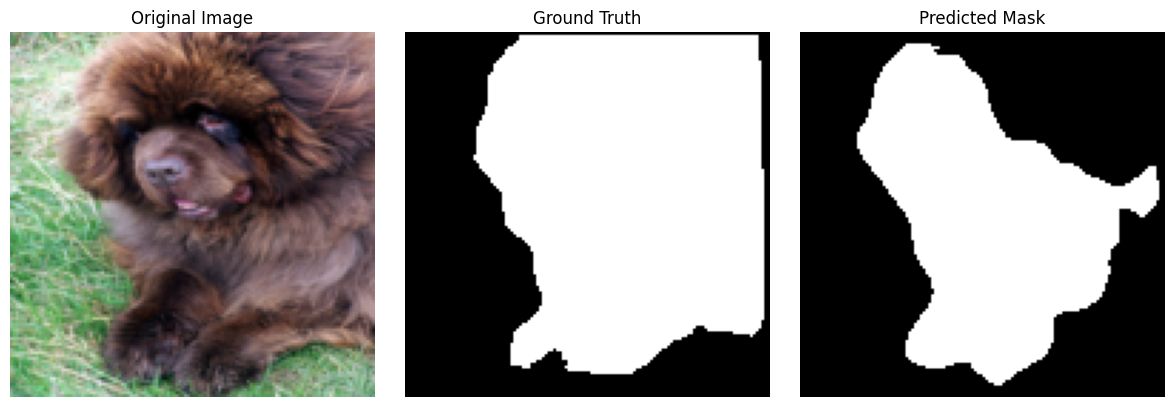

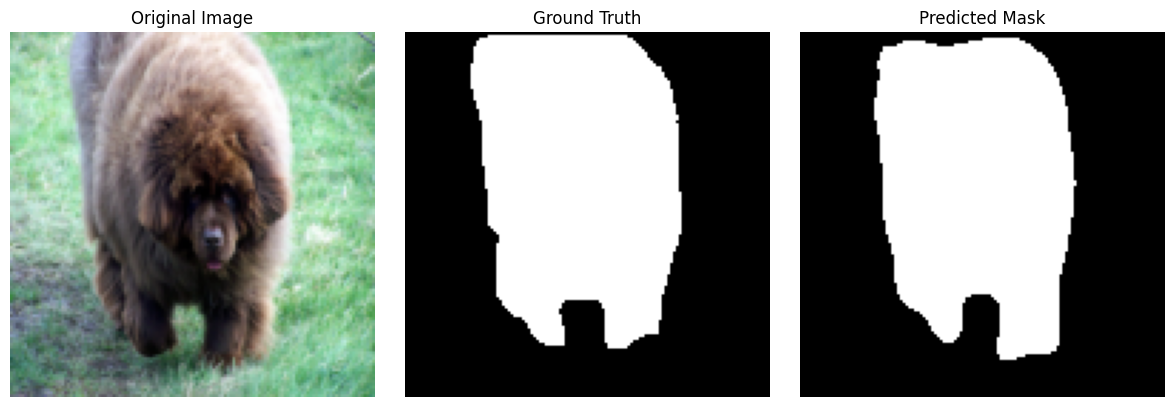

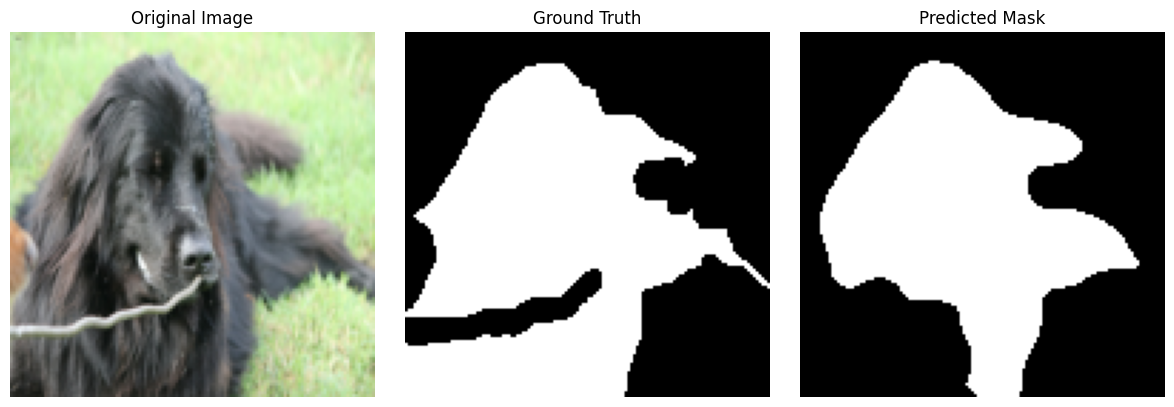

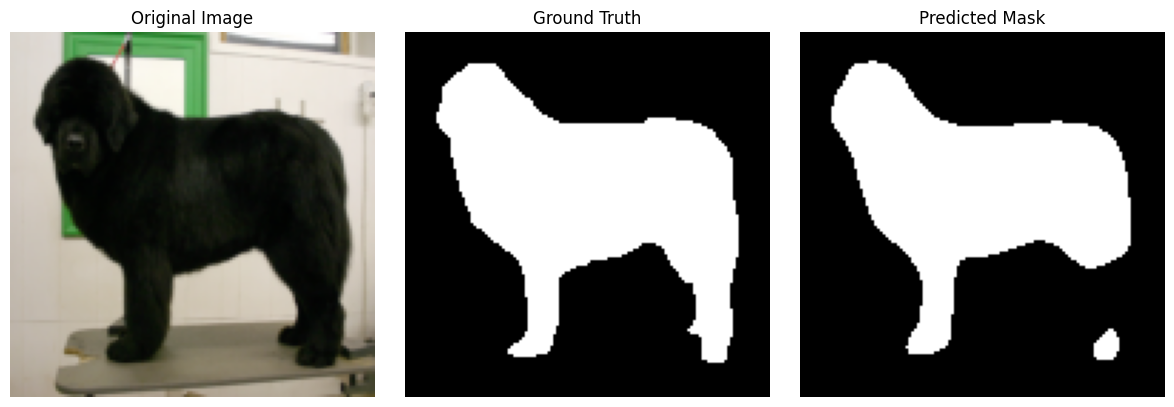

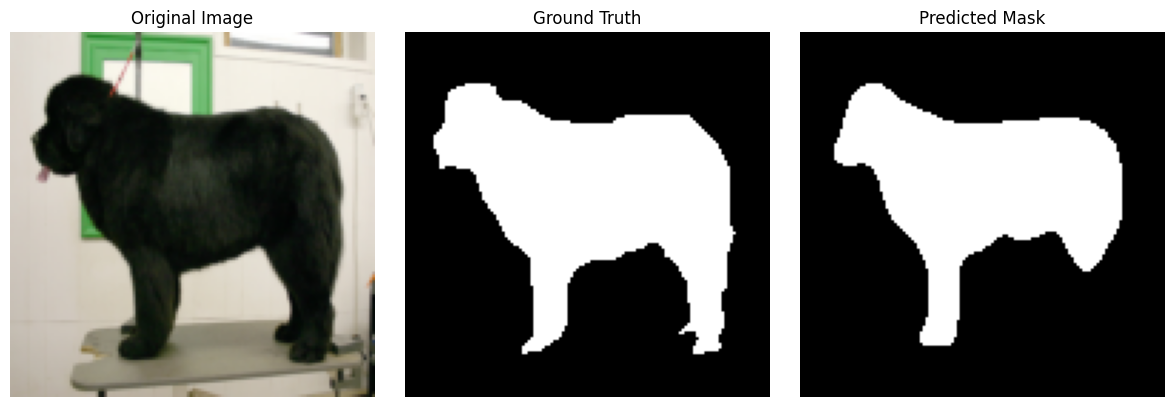

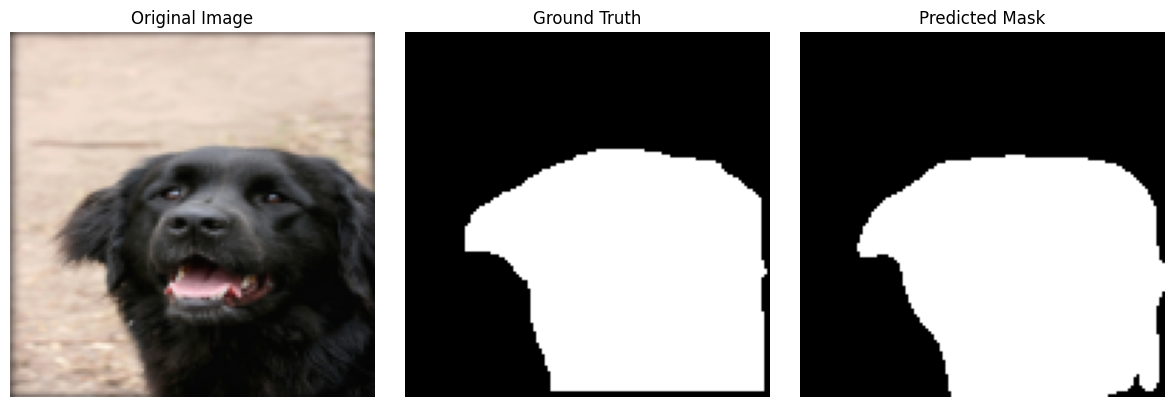

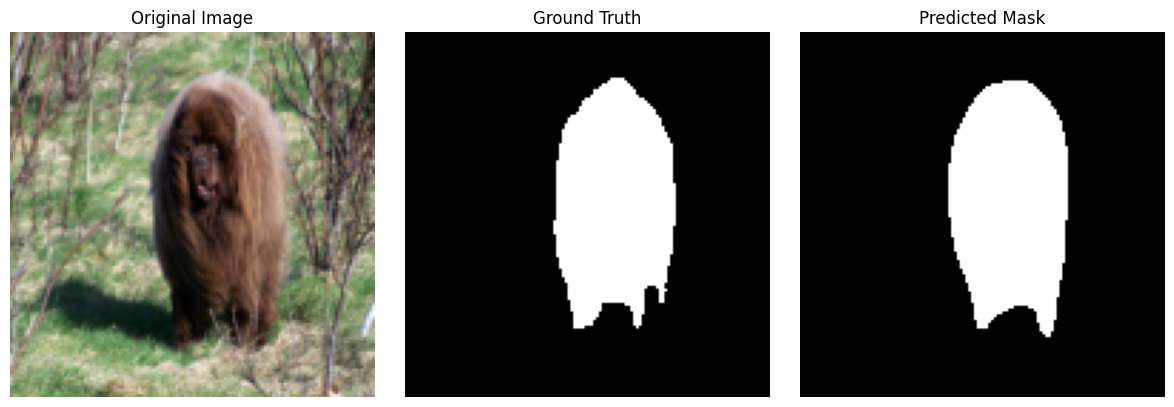

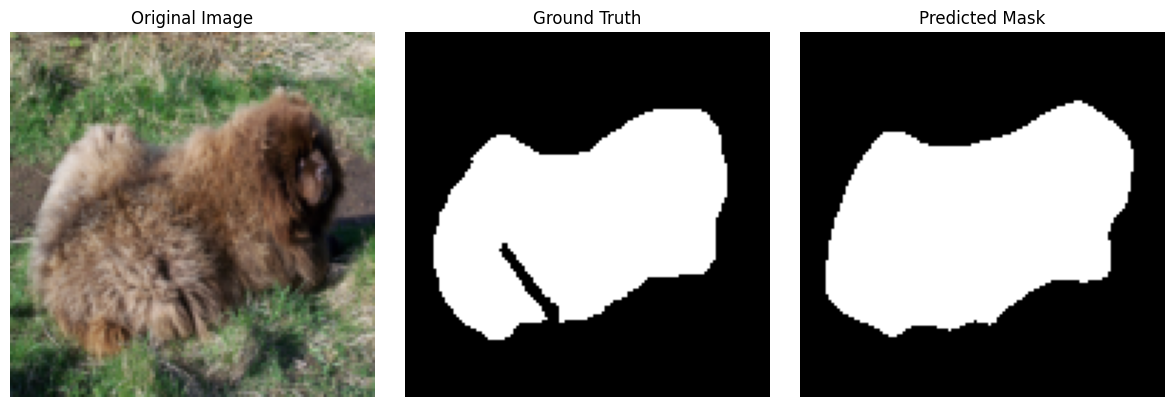

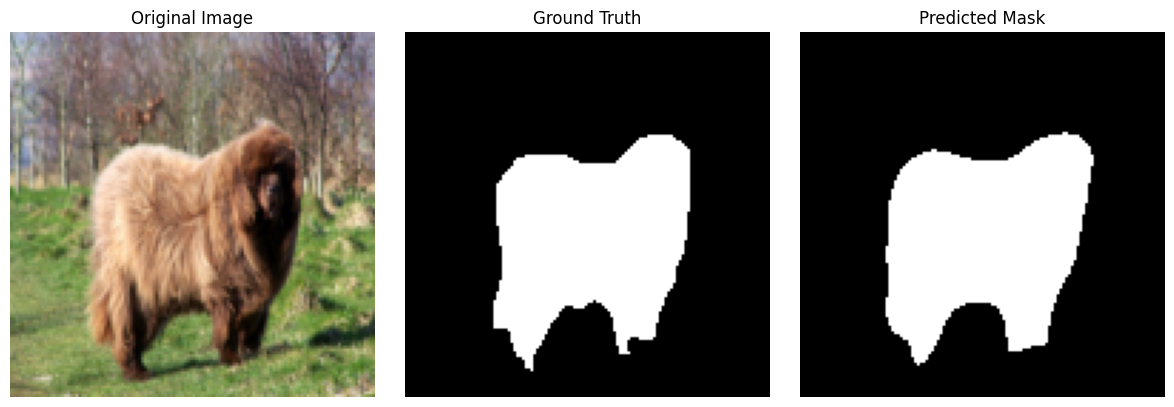

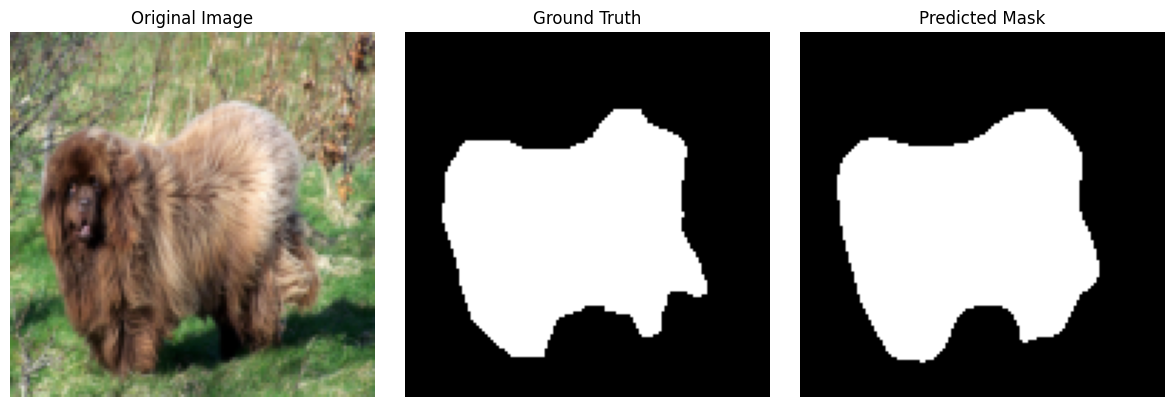

In [ ]:
def show_multiple_predictions(model, dataloader, num_samples=10):
    model.eval()
    with torch.no_grad():
        count = 0
        for images, masks in dataloader:
            images = images.to(device)
            preds = model(images)
            preds = (preds > 0.5).float()

            for i in range(images.shape[0]):
                if count >= num_samples:
                    return
                fig, axs = plt.subplots(1, 3, figsize=(12, 4))
                axs[0].imshow(images[i].permute(1, 2, 0).cpu())
                axs[0].set_title("Original Image")
                axs[1].imshow(masks[i][0].cpu(), cmap='gray')
                axs[1].set_title("Ground Truth")
                axs[2].imshow(preds[i][0].cpu(), cmap='gray')
                axs[2].set_title("Predicted Mask")
                for ax in axs: ax.axis('off')
                plt.tight_layout()
                plt.show()
                count += 1
show_multiple_predictions(model, test_loader, num_samples=10)


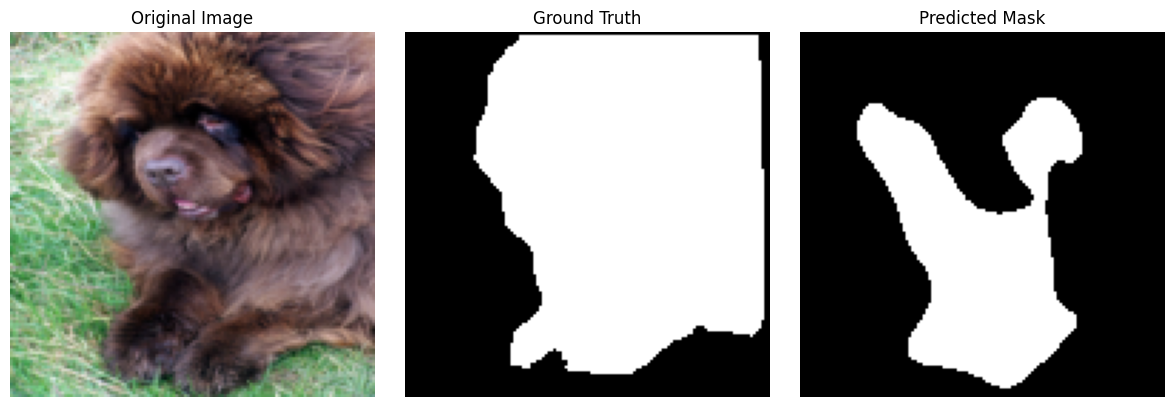

In [ ]:
def show_predictions(model, dataloader):
    model.eval()
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            preds = model(images)
            preds = (preds > 0.5).float()

            fig, axs = plt.subplots(1, 3, figsize=(12, 4))
            axs[0].imshow(images[0].permute(1, 2, 0).cpu())
            axs[0].set_title("Original Image")
            axs[1].imshow(masks[0][0].cpu(), cmap='gray')
            axs[1].set_title("Ground Truth")
            axs[2].imshow(preds[0][0].cpu(), cmap='gray')
            axs[2].set_title("Predicted Mask")
            for ax in axs: ax.axis('off')
            plt.tight_layout()
            plt.show()
            break

show_predictions(model, test_loader)